# This is a sample Jupyter Notebook

Below is an example of a code cell. 
Put your cursor into the cell and press Shift+Enter to execute it and select the next one, or click 'Run Cell' button.

Press Double Shift to search everywhere for classes, files, tool windows, actions, and settings.

To learn more about Jupyter Notebooks in PyCharm, see [help](https://www.jetbrains.com/help/pycharm/ipython-notebook-support.html).
For an overview of PyCharm, go to Help -> Learn IDE features or refer to [our documentation](https://www.jetbrains.com/help/pycharm/getting-started.html).

In [1]:
words = open('names.txt', 'r').read().splitlines()


In [2]:
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [3]:
len(words)

32033

In [4]:
min(len(w) for w in words)

2

In [5]:
max(len(w) for w in words)

15

In [18]:
b = {}
for w in words:
    chs = ['<S>'] + list(w) + ['<E>']
    for ch1, ch2 in zip(chs, chs[1:]):
        bigram = (ch1, ch2)
        b[bigram] = b.get(bigram, 0) + 1


In [ ]:
sorted(b.items(), key = lambda kv: -kv[1])

In [68]:
import torch

In [69]:
N = torch.zeros((27,27), dtype = torch.int32)


In [70]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i +1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}

In [71]:

for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1, ix2] += 1

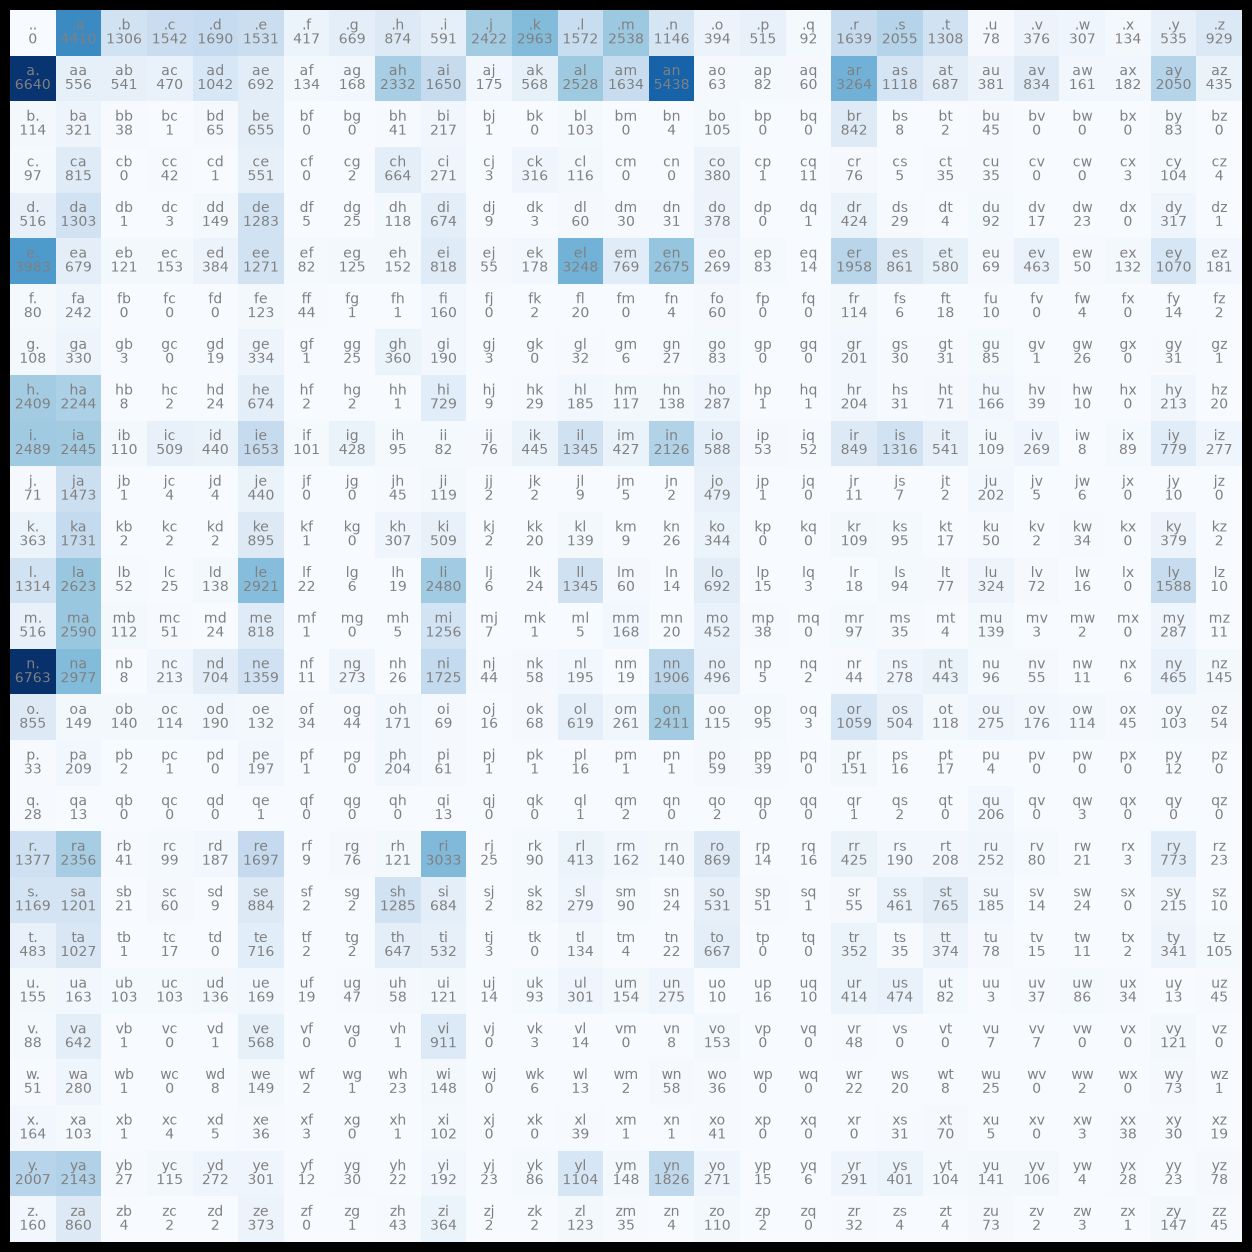

In [72]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color='gray')
plt.axis('off');

In [73]:
N[0]

tensor([   0, 4410, 1306, 1542, 1690, 1531,  417,  669,  874,  591, 2422, 2963,
        1572, 2538, 1146,  394,  515,   92, 1639, 2055, 1308,   78,  376,  307,
         134,  535,  929], dtype=torch.int32)

In [74]:
p = N[0].float()
p = p/p.sum()
p

tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])

In [76]:
g = torch.Generator().manual_seed(2147483647)
ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
itos[ix]

'c'

In [77]:
g = torch.Generator().manual_seed(2147483647)
p = torch.rand(3, generator=g)
p = p / p.sum()
p

tensor([0.6064, 0.3033, 0.0903])

In [63]:
torch.multinomial(p, num_samples=100, replacement=True, generator=g)

tensor([0, 2, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1,
        1, 0, 1, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0,
        2, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0,
        1, 0, 2, 0])

In [86]:
P = (N+1).float()
P /= P.sum(1, keepdims=True)

In [91]:
P[1].sum()

tensor(1.0000)

In [92]:
g = torch.Generator().manual_seed(2147483647)


for i in range(5):
    out = []
    ix = 0
    while True:
        p = P[ix]
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
          break
    print(''.join(out))

cexze.
momasurailezitynn.
konimittain.
llayn.
ka.


In [93]:
# GOAL: maximize likelihood of the data w.r.t. model parameters (statistical modeling)
# equivalent to maximizing the log likelihood (because log is monotonic)
# equivalent to minimizing the negative log likelihood
# equivalent to minimizing the average negative log likelihood

# log(a*b*c) = log(a) + log(b) + log(c)

In [94]:
log_likelihood = 0.0
n = 0

for w in words:
#for w in ["andrejq"]:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    prob = P[ix1, ix2]
    logprob = torch.log(prob)
    log_likelihood += logprob
    n += 1
    #print(f'{ch1}{ch2}: {prob:.4f} {logprob:.4f}')

print(f'{log_likelihood=}')
nll = -log_likelihood
print(f'{nll=}')
print(f'{nll/n}')

log_likelihood=tensor(-559951.5625)
nll=tensor(559951.5625)
2.4543561935424805


In [96]:
# create the training set of bigrams (x,y)

xs, ys = [], []

for w in words[:1]:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    xs.append(ix1)
    ys.append(ix2)

xs = torch.tensor(xs)
ys = torch.tensor(ys)

In [102]:
import torch.nn.functional as F
xenc = F.one_hot(xs, num_classes=27).float()
xenc

tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [103]:
xenc.shape

torch.Size([5, 27])

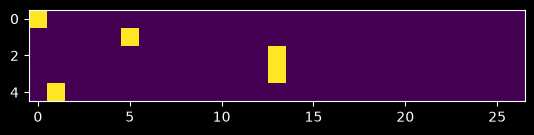

In [104]:
plt.imshow(xenc)

In [105]:
xenc.dtype

torch.float32

In [109]:
W = torch.randn((27, 27))
xenc @ W # matrix multiplyer in pytorch "@"

tensor([[ 0.3019,  1.0619, -0.5167,  0.7880, -0.8135,  0.2964,  0.6396, -0.0553,
          0.3485,  1.0690,  0.4513,  0.2500,  0.6413,  0.0087,  0.1468,  1.9782,
         -1.3655,  0.2640, -0.9427, -1.2267, -0.7300,  0.0560, -0.4077,  0.1563,
         -0.8461, -0.9563, -0.3358],
        [-0.0149, -0.6095, -0.7764,  0.2429,  0.0298, -0.3488,  0.3726,  0.6918,
         -0.8361, -2.0838, -0.0195,  1.5184,  0.9657,  0.5481,  0.5500, -0.0715,
         -0.1236,  1.6779, -0.6829,  0.5334, -1.5973,  0.8062, -0.3946,  1.0696,
         -0.0060,  0.7141,  0.1313],
        [-0.2558, -0.2920,  0.3778, -1.1374, -0.2933, -0.5858, -0.7722, -1.2894,
          1.1632,  1.1053,  1.8095, -1.6761,  0.0918,  0.1644, -0.4805,  0.6473,
         -1.6870,  1.1619,  0.2470,  0.1971, -1.8354, -0.0874, -0.3610,  0.8409,
          0.2431, -0.1866, -1.5498],
        [-0.2558, -0.2920,  0.3778, -1.1374, -0.2933, -0.5858, -0.7722, -1.2894,
          1.1632,  1.1053,  1.8095, -1.6761,  0.0918,  0.1644, -0.4805,  0.6473

In [ ]:
 # (5,27) @ (27,27) = (5,27)

In [118]:
nlls = torch.zeros(5)
for i in range(5):
  # i-th bigram:
  x = xs[i].item() # input.txt character index
  y = ys[i].item() # label character index
  print('--------')
  print(f'bigram example {i+1}: {itos[x]}{itos[y]} (indexes {x},{y})')
  print('input.txt to the neural net:', x)
  print('output probabilities from the neural net:', probs[i])
  print('label (actual next character):', y)
  p = probs[i, y]
  print('probability assigned by the net to the the correct character:', p.item())
  logp = torch.log(p)
  print('log likelihood:', logp.item())
  nll = -logp
  print('negative log likelihood:', nll.item())
  nlls[i] = nll

print('=========')
print('average negative log likelihood, i.e. loss =', nlls.mean().item())

--------
bigram example 1: .e (indexes 0,5)
input to the neural net: 0
output probabilities from the neural net: tensor([0.0363, 0.0776, 0.0160, 0.0590, 0.0119, 0.0361, 0.0508, 0.0254, 0.0380,
        0.0781, 0.0421, 0.0344, 0.0509, 0.0271, 0.0311, 0.1939, 0.0068, 0.0349,
        0.0104, 0.0079, 0.0129, 0.0284, 0.0178, 0.0314, 0.0115, 0.0103, 0.0192])
label (actual next character): 5
probability assigned by the net to the the correct character: 0.03606615215539932
log likelihood: -3.3224005699157715
negative log likelihood: 3.3224005699157715
--------
bigram example 2: em (indexes 5,13)
input to the neural net: 5
output probabilities from the neural net: tensor([0.0245, 0.0135, 0.0114, 0.0317, 0.0256, 0.0175, 0.0361, 0.0497, 0.0108,
        0.0031, 0.0244, 0.1135, 0.0653, 0.0430, 0.0431, 0.0231, 0.0220, 0.1331,
        0.0126, 0.0424, 0.0050, 0.0557, 0.0168, 0.0724, 0.0247, 0.0508, 0.0283])
label (actual next character): 13
probability assigned by the net to the the correct character: 

In [128]:
# randomly initialize 27 neurons ' weights. each neuron receives 27 inputs
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27,27), generator=g, requires_grad=True)

In [158]:
# forward pass
xenc = F.one_hot(xs, num_classes=27).float()
logits = (xenc @ W) # log-counts
counts = logits.exp()
probs = counts / counts.sum(1, keepdims=True)
# btw: the last 2 lines here are together called a 'softmax'
loss = -probs[torch.arange(5), ys].log().mean()

In [159]:
print(loss.item())

3.6295523643493652


In [160]:
# backward pass
W.grad = None # set to zero in pytorch
loss.backward()


In [161]:
W.data += -0.1 * W.grad

In [163]:
# create the dataset
xs, ys = [], []
for w in words:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    xs.append(ix1)
    ys.append(ix2)
xs = torch.tensor(xs)
ys = torch.tensor(ys)
num = xs.nelement()
print('number of examples: ', num)

# initialize the 'network'
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g, requires_grad=True)

number of examples:  228146


In [169]:
# gradient descent
for k in range(100):

  # forward pass
  xenc = F.one_hot(xs, num_classes=27).float() # input.txt to the network: one-hot encoding
  logits = xenc @ W # predict log-counts
  counts = logits.exp() # counts, equivalent to N
  probs = counts / counts.sum(1, keepdims=True) # probabilities for next character
  loss = -probs[torch.arange(num), ys].log().mean() + 0.01*(W**2).mean()
  print(loss.item())

  # backward pass
  W.grad = None # set to zero the gradient
  loss.backward()

  # update
  W.data += -100 * W.grad

2.4814913272857666
2.481475591659546
2.4814600944519043
2.4814453125
2.4814300537109375
2.4814157485961914
2.481401205062866
2.481387138366699
2.4813737869262695
2.4813599586486816
2.481346845626831
2.4813339710235596
2.481321096420288
2.4813084602355957
2.4812963008880615
2.4812846183776855
2.4812731742858887
2.481262683868408
2.4812536239624023
2.4812510013580322
2.4812631607055664
2.4813194274902344
2.481491804122925
2.482029438018799
2.4833502769470215
2.487530469894409
2.493572235107422
2.5123543739318848
2.5029807090759277
2.511728286743164
2.498359203338623
2.5101373195648193
2.501636505126953
2.5129144191741943
2.499091386795044
2.5090532302856445
2.5011940002441406
2.513707399368286
2.4992520809173584
2.5082101821899414
2.5010933876037598
2.5144031047821045
2.49918794631958
2.5073904991149902
2.501138687133789
2.5151216983795166
2.499025821685791
2.5065131187438965
2.5012476444244385
2.5158958435058594
2.4988186359405518
2.5055620670318604
2.501380205154419
2.516713857650757
2

In [171]:
# finally, sample from the 'neural net' model
g = torch.Generator().manual_seed(2147483647)

for i in range(10):

  out = []
  ix = 0
  while True:

    # ----------
    # BEFORE:
    #p = P[ix]
    # ----------
    # NOW:
    xenc = F.one_hot(torch.tensor([ix]), num_classes=27).float()
    logits = xenc @ W # predict log-counts
    counts = logits.exp() # counts, equivalent to N
    p = counts / counts.sum(1, keepdims=True) # probabilities for next character
    # ----------

    ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
    out.append(itos[ix])
    if ix == 0:
      break
  print(''.join(out))

cexze.
moma.
mikilezityha.
konimitta.
n.
llayn.
ka.
da.
staiyaubrtthrigotai.
moliellavo.
